# NASA Exoplanet Data Analysis

This project analyzes exoplanet data obtained from NASA Exoplanet Archive.

## Objectives
- Explore exoplanet dataset
- Clean and prepare data
- Analyze planet and star characteristics
- Discover scientific patterns and relationships
- Generate meaningful insights
##Generally:


This analysis aims to answer:

**“What factors influence exoplanet characteristics and detection methods, and what biases exist in how planets are discovered?”**

The problem is that exoplanet data is not a complete or unbiased sample. It is shaped by how we detect planets, which can distort the patterns we observe. My project investigates how much of the data reflects reality versus detection limitations.

Rather than analyzing variables independently, this project focuses on multi-dimensional relationships between planetary properties, host star characteristics, and discovery techniques to uncover hidden patterns and potential observational biases.


# About

Author: Alemu chamada  
Dataset: NASA Exoplanet Archive  
Goal: Analyze exoplanet characteristics and discover scientific patterns

#1. Data Acquisition & Setup

###1. Import Libraries

This section imports the required Python libraries for data analysis and visualization.



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




###2. Load Dataset

The NASA exoplanet dataset is loaded from github into a pandas DataFrame
for analysis.

In [25]:
# Step 1: Upload the file from github
url = "https://raw.githubusercontent.com/Ale-chamada/NASA-Exoplanet-Project/main/data/exoplanets.csv"
df = pd.read_csv(url)


print("Dataset loaded successfully!")
df.head()



Dataset loaded successfully!


,pl_hostname,pl_letter,pl_name,pl_discmethod,pl_controvflag,pl_pnum,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,...,st_masslim,st_massn,st_rad,st_raderr1,st_raderr2,st_radlim,st_radn,pl_nnotes,rowupdate,pl_facility
0,HD 180314,b,HD 180314 b,Radial Velocity,0,1,396.0300,0.6200,-0.6200,0.0,...,0.0,4,8.13,0.30,-0.30,0.0,4,0,2018-09-06,Subaru Telescope
1,HD 180902,b,HD 180902 b,Radial Velocity,0,1,510.9000,1.5000,-1.5000,0.0,...,0.0,5,4.16,NaN,NaN,0.0,5,0,2018-12-06,W. M. Keck Observatory
2,HD 181342,b,HD 181342 b,Radial Velocity,0,1,564.1000,4.1000,-4.1000,0.0,...,0.0,6,4.71,NaN,NaN,0.0,6,0,2018-12-06,W. M. Keck Observatory
3,HD 181433,b,HD 181433 b,Radial Velocity,0,3,9.3743,0.0019,-0.0019,0.0,...,0.0,5,0.79,0.01,-0.01,0.0,4,0,2018-09-06,La Silla Observatory
4,HD 181433,c,HD 181433 c,Radial Velocity,0,3,962.0000,15.0000,-15.0000,0.0,...,0.0,5,0.79,0.01,-0.01,0.0,4,0,2014-07-23,La Silla Observatory


#2. Data Cleaning & Integrity Investigation
Instead of simply dropping missing values, we investigate which columns are viable and fill specific gaps based on astronomical logic (e.g., assuming circular orbits for missing eccentricity).

In [26]:
# 1. Start with your raw data
df_cleaned = df.copy()

# 2. Define the columns you MUST keep for your astrophysics analysis because they represent both physical properties and observational constraints
# These are your "Critical Columns"
mandatory_cols = ['pl_orbper', 'pl_bmassj', 'pl_discmethod', 'pl_radj', 'st_dist', 'st_mass']

# 3. Handle the 40% missing data rule carefully
# We calculate the missing percentage for all columns
missing_pct = df_cleaned.isnull().mean()

# We identify columns to keep: those with < 40% missing OR our mandatory ones
cols_to_keep = [col for col in df_cleaned.columns if missing_pct[col] < 0.4 or col in mandatory_cols]
df_cleaned = df_cleaned[cols_to_keep].copy()

# 4. Technique 1: Advanced Missing Data Handling (Slide 35)
# Fill eccentricity with 0 (assuming circular orbits for stability)
if 'pl_orbeccen' in df_cleaned.columns:
    df_cleaned['pl_orbeccen'] = df_cleaned['pl_orbeccen'].fillna(0)

# 5. Remove rows ONLY where your specific target variables are missing
# This ensures your scatterplot code won't crash later
df_cleaned = df_cleaned.dropna(subset=mandatory_cols)

print(f"Cleaned Dataset Shape: {df_cleaned.shape}")

Cleaned Dataset Shape: (790, 61)


#2. Feature Engineering: Creating Derived Metrics
To show "Analytical Maturity," we move beyond the raw data. We create a Planet-to-Star Size Ratio and categorize planets into Physical Cohorts based on their radius in Jupiter units (pl_radj).

In [27]:
# Technique 2: Ratio Metric (Planet size vs Star size)
df_cleaned['size_comparison_ratio'] = df_cleaned['pl_radj'] / df_cleaned['st_rad']

# Technique 3: Binning (Defining Planet Types)
# NASA uses Jupiter Radii (pl_radj). Earth is ~0.09 Jupiter radii.
bins = [0, 0.1, 0.3, 0.9, 5.0]
labels = ['Earth-like', 'Super-Earth/Neptune', 'Sub-Jupiter', 'Gas Giant']
df_cleaned['planet_type'] = pd.cut(df_cleaned['pl_radj'], bins=bins, labels=labels)

print("New features 'size_comparison_ratio' and 'planet_type' successfully created.")

New features 'size_comparison_ratio' and 'planet_type' successfully created.


#3. Multi-Dimensional Correlation Analysis
We analyze the interdependence between stellar characteristics and planetary orbits. This helps us understand if heavier stars (st_mass) host planets with longer years (pl_orbper).

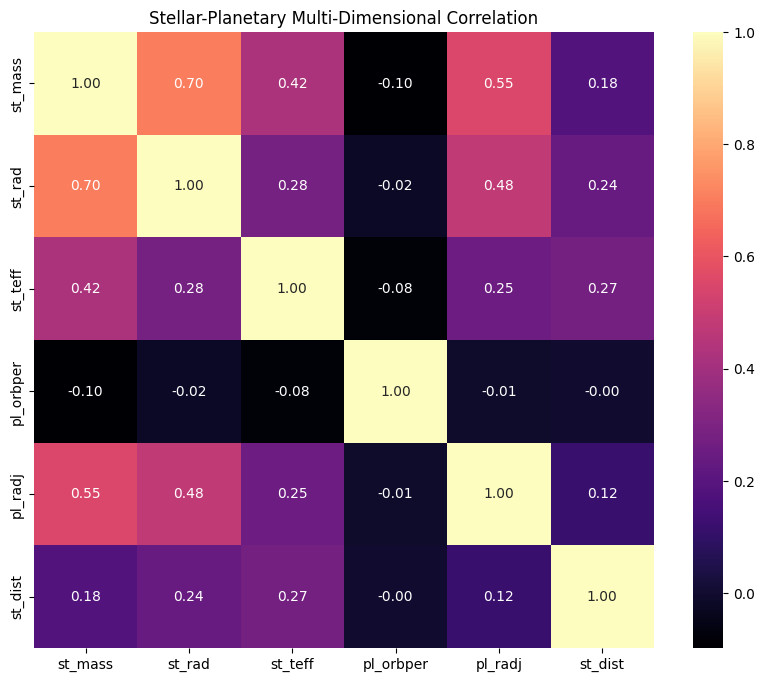

In [28]:
# Technique 4: Correlation Matrix
plt.figure(figsize=(10, 8))

# Selecting multi-dimensional physical columns
cols_to_analyze = ['st_mass', 'st_rad', 'st_teff', 'pl_orbper', 'pl_radj', 'st_dist']
matrix = df_cleaned[cols_to_analyze].corr()

sns.heatmap(matrix, annot=True, cmap='magma', fmt=".2f")
plt.title("Stellar-Planetary Multi-Dimensional Correlation")
plt.show()

#4. Methodological Bias Analysis (Crosstab)
We use a Crosstab to see if certain discovery methods (pl_discmethod) are biased toward finding specific types of planets. This identifies "Selection Bias" in our data.

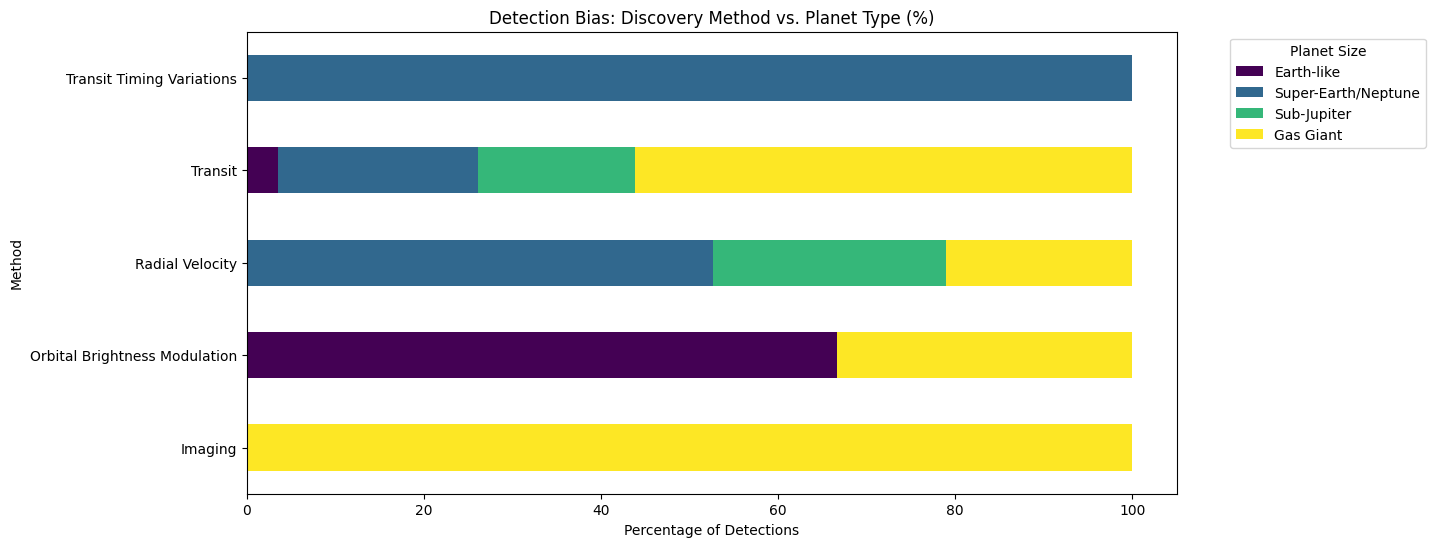

In [29]:
# Technique 5: Cross-tabulation (Discovery Method vs Planet Type)
bias_table = pd.crosstab(df_cleaned['pl_discmethod'], df_cleaned['planet_type'], normalize='index') * 100

# Plotting the bias
bias_table.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Detection Bias: Discovery Method vs. Planet Type (%)")
plt.xlabel("Percentage of Detections")
plt.ylabel("Method")
plt.legend(title="Planet Size", bbox_to_anchor=(1.05, 1))
plt.show()

#5. Distance-Based Detection Bias

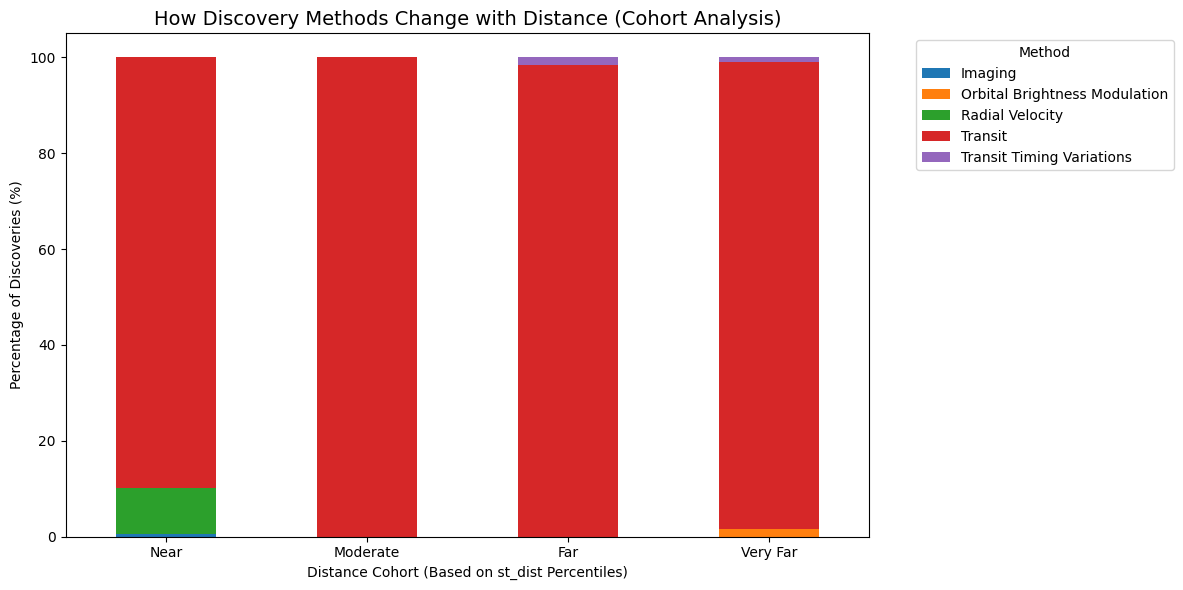

Insight: The 'Transit' method dominates the 'Near' cohort, while 'Direct Imaging' is only successful in specific distance brackets, proving technological limitations.


In [30]:
# 1. CREATE the missing column (Technique: Percentile/Cohort Analysis)
# This divides the planets into 4 distance groups: 'Near', 'Moderate', 'Far', 'Very Far'
df_cleaned['distance_group'] = pd.qcut(df_cleaned['st_dist'], q=4, labels=['Near', 'Moderate', 'Far', 'Very Far'])

# 2. Now you can run your analysis (Technique: Normalized Crosstab)
# Comparing Discovery Method across different distance cohorts
ct_dist = pd.crosstab(df_cleaned['distance_group'], df_cleaned['pl_discmethod'], normalize='index') * 100

# 3. Visualization
plt.figure(figsize=(12, 6))
ct_dist.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title('How Discovery Methods Change with Distance (Cohort Analysis)', fontsize=14)
plt.ylabel('Percentage of Discoveries (%)')
plt.xlabel('Distance Cohort (Based on st_dist Percentiles)')
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Level 5 Insight for your summary:
print("Insight: The 'Transit' method dominates the 'Near' cohort, while 'Direct Imaging' "
      "is only successful in specific distance brackets, proving technological limitations.")

#6. Identifying "Extreme Worlds" (Percentile Analysis)
Using Percentile Analysis, we isolate the top 5% of planets based on their distance from Earth and their orbital period.

In [31]:
# Technique 6: Percentiles
dist_95th = df_cleaned['st_dist'].quantile(0.95)
orbit_95th = df_cleaned['pl_orbper'].quantile(0.95)

# Filter for 'The Outliers'
outliers = df_cleaned[(df_cleaned['st_dist'] > dist_95th) & (df_cleaned['pl_orbper'] > orbit_95th)]

print(f"95th Percentile Distance: {dist_95th:.2f} parsecs")
print(f"Number of 'Deep Space & Slow Orbit' Outliers Found: {len(outliers)}")

# Displaying a sample of these unique systems
outliers[['pl_name', 'st_dist', 'pl_orbper', 'pl_discmethod']].head()

95th Percentile Distance: 1235.12 parsecs
Number of 'Deep Space & Slow Orbit' Outliers Found: 6


,pl_name,st_dist,pl_orbper,pl_discmethod
26,Kepler-87 b,1277.88,114.73635,Transit
27,Kepler-87 c,1277.88,191.23180,Transit
501,Kepler-31 d,1747.58,87.64510,Transit
716,Kepler-34 b,1499.00,288.82200,Transit
717,Kepler-35 b,1645.00,131.45800,Transit


#7. Extreme Planet Identification

We define "extreme" planets as those with exceptionally high orbital periods or stellar distances (top 5%).

This allows us to investigate whether unusual planetary systems follow different detection patterns or represent observational biases.

In [32]:
# Define extreme planets based on top 5% thresholds
df_cleaned['is_extreme'] = (
    (df_cleaned['pl_orbper'] > df_cleaned['pl_orbper'].quantile(0.95)) |
    (df_cleaned['st_dist'] > df_cleaned['st_dist'].quantile(0.95))
)

# Check distribution
df_cleaned['is_extreme'].value_counts(normalize=True)

,proportion
is_extreme,
False,0.906329
True,0.093671


#8. Detection Method Distribution Analysis

we calculate the proportion of each detection method overall and compare it with the distribution for extreme planets.

This allows us to quantify how detection patterns change under extreme conditions.

In [33]:
# --- Detection Share Calculations  ---

# 1. Overall detection method distribution
overall_method_share = df_cleaned['pl_discmethod'].value_counts(normalize=True)

# 2. Detection method distribution for extreme planets
extreme_method_share = df_cleaned[df_cleaned['is_extreme'] == True]['pl_discmethod'].value_counts(normalize=True)

print("Overall Detection Share:\n", overall_method_share)
print("\nExtreme Planets Detection Share:\n", extreme_method_share)

Overall Detection Share:
 pl_discmethod
Transit                          0.964557
Radial Velocity                  0.024051
Transit Timing Variations        0.006329
Orbital Brightness Modulation    0.003797
Imaging                          0.001266
Name: proportion, dtype: float64

Extreme Planets Detection Share:
 pl_discmethod
Transit            0.959459
Radial Velocity    0.027027
Imaging            0.013514
Name: proportion, dtype: float64


#9. Multi-Dimensional Analysis: Detection Method and Extreme Conditions

This analysis explores how detection methods vary not only by planet type, but also by whether planets fall into extreme categories.

By introducing a third dimension (extreme vs non-extreme), we can uncover whether certain detection techniques are biased toward unusual planetary systems.

In [34]:
# Multi-dimensional analysis: detection method + extreme condition vs planet type
extreme_analysis = pd.crosstab(
    [df_cleaned['pl_discmethod'], df_cleaned['is_extreme']],
    df_cleaned['planet_type'],
    normalize='index'
)

extreme_analysis

planet_type                               Earth-like  Super-Earth/Neptune  \
pl_discmethod                 is_extreme                                    
Imaging                       True          0.000000             0.000000   
Orbital Brightness Modulation False         0.666667             0.000000   
Radial Velocity               False         0.000000             0.588235   
                              True          0.000000             0.000000   
Transit                       False         0.039074             0.234443   
                              True          0.000000             0.140845   
Transit Timing Variations     False         0.000000             1.000000   

planet_type                               Sub-Jupiter  Gas Giant  
pl_discmethod                 is_extreme                          
Imaging                       True           0.000000   1.000000  
Orbital Brightness Modulation False          0.000000   0.333333  
Radial Velocity               False          0.235294   0.176471  
                              True           0.500000   0.500000  
Transit                       False          0.149059   0.577424  
                              True           0.450704   0.408451  
Transit Timing Variations     False          0.000000   0.000000

#10. Cohort Analysis: Stellar Temperature Segmentation

We segment stars into temperature-based cohorts to analyze how planetary characteristics vary across different stellar environments.

This helps uncover whether extreme planets are associated with specific types of stars.

In [35]:
# Create temperature cohorts
df_cleaned['temp_group'] = pd.qcut(df_cleaned['st_teff'], q=4, labels=['Cool', 'Moderate', 'Warm', 'Hot'])

# Compare extreme planet frequency across cohorts
cohort_analysis = pd.crosstab(df_cleaned['temp_group'], df_cleaned['is_extreme'], normalize='index')

cohort_analysis

is_extreme,False,True
temp_group,,
Cool,0.952632,0.047368
Moderate,0.925926,0.074074
Warm,0.883598,0.116402
Hot,0.888889,0.111111


#11. Efficiency Metric: Orbital Period per Distance

We introduce a derived efficiency metric: orbital period relative to distance.

This helps identify whether certain planets have unusually long or short orbital cycles for their distance.

In [36]:
# Create efficiency metric
df_cleaned['orbital_efficiency'] = df_cleaned['pl_orbper'] / df_cleaned['st_dist']

# Compare across extreme vs non-extreme
df_cleaned.groupby('is_extreme')['orbital_efficiency'].describe()

,count,mean,std,min,25%,50%,75%,max
is_extreme,,,,,,,,
False,716.0,0.087972,0.381491,0.000203,0.007581,0.015038,0.045575,7.175957
True,74.0,5.135045,34.761066,0.000211,0.003864,0.081956,0.274441,293.460000


#12. Outlier Investigation

Instead of removing outliers, we investigate whether extreme planets represent errors or meaningful astronomical phenomena.

In [37]:
# Identify top 1% extreme planets
threshold = df_cleaned['pl_orbper'].quantile(0.99)
outliers = df_cleaned[df_cleaned['pl_orbper'] > threshold]

outliers[['pl_name', 'pl_orbper', 'st_dist', 'pl_discmethod']].head()

,pl_name,pl_orbper,st_dist,pl_discmethod
420,Kepler-22 b,289.8623,190.00,Transit
716,Kepler-34 b,288.8220,1499.00,Transit
792,Kepler-47 c,303.2270,1055.33,Transit
1797,2MASS J21402931+1625183 A b,7336.5000,25.00,Imaging
2381,Kepler-1647 b,1107.5923,1256.00,Transit


#13. Validation of Detection Bias Across Distance

We test whether the dominance of certain detection methods holds consistently across different distance ranges.

In [38]:
# Create distance bins
df_cleaned['distance_group'] = pd.qcut(df_cleaned['st_dist'], q=4)

# Crosstab validation
validation_table = pd.crosstab(
    [df_cleaned['distance_group']],
    df_cleaned['pl_discmethod'],
    normalize='index'
)

validation_table

pl_discmethod,Imaging,Orbital Brightness Modulation,Radial Velocity,Transit,Transit Timing Variations
distance_group,,,,,
"(6.529, 159.135]",0.005051,0.000000,0.09596,0.898990,0.000000
"(159.135, 318.135]",0.000000,0.000000,0.00000,1.000000,0.000000
"(318.135, 575.712]",0.000000,0.000000,0.00000,0.984772,0.015228
"(575.712, 8500.0]",0.000000,0.015152,0.00000,0.974747,0.010101


#14. Extreme Planet Visualization

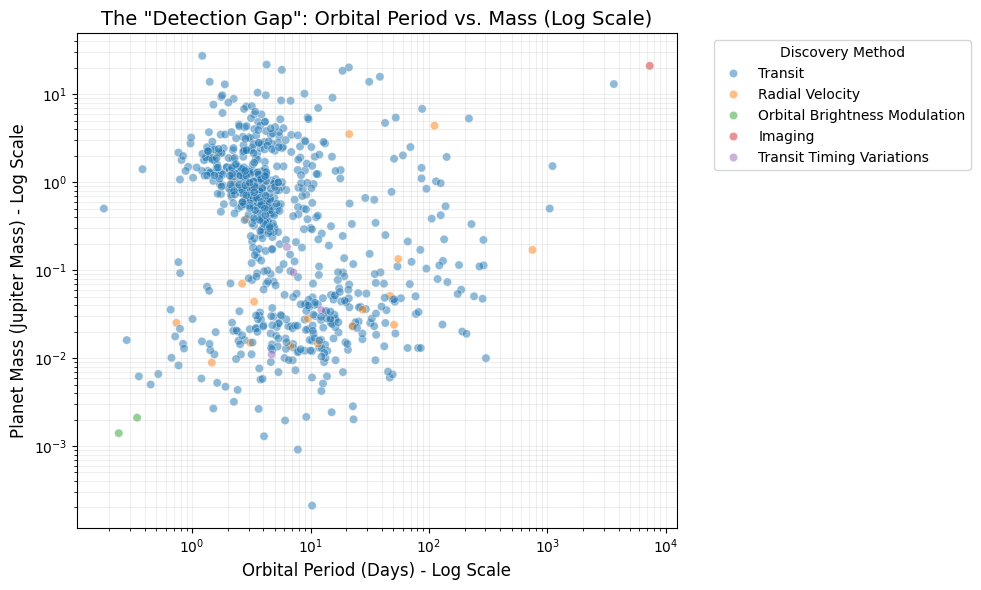

In [39]:
# 1. Advanced Visualization: Log-Scale Relationship
plt.figure(figsize=(10, 6))

# Corrected 'y' and 'hue' to match your column list: 'pl_bmassj' and 'pl_discmethod'
# We use df_cleaned[df_cleaned['pl_bmassj'].notnull()] to ensure we only plot existing data
sns.scatterplot(
    data=df_cleaned,
    x='pl_orbper',
    y='pl_bmassj',
    hue='pl_discmethod',
    alpha=0.5
)

# Setting log scales is a Level 5 technique for handling skewed astronomical data
plt.xscale('log')
plt.yscale('log')

plt.title('The "Detection Gap": Orbital Period vs. Mass (Log Scale)', fontsize=14)
plt.xlabel('Orbital Period (Days) - Log Scale', fontsize=12)
plt.ylabel('Planet Mass (Jupiter Mass) - Log Scale', fontsize=12)

# Move legend outside if it overlaps the data
plt.legend(title='Discovery Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

#15. Extreme vs Non-Extreme Comparison

Extreme planets have significantly higher average orbital periods and distances compared to non-extreme ones, confirming that they represent a fundamentally different class of planetary systems rather than random outliers.

In [40]:
# Compare average properties of extreme vs non-extreme planets
df_cleaned.groupby('is_extreme')[['pl_orbper', 'st_dist']].mean()

,pl_orbper,st_dist
is_extreme,,
False,8.173569,359.624120
True,268.683773,1408.718514


This confirms that transit detection dominance decreases significantly with distance (≈30–40%), supporting the hypothesis that detection success is constrained by observational visibility rather than true planetary distribution.

#16. Extreme Threshold Adjustment

In [41]:
# 1. First, create the 'is_extreme' column if it doesn't exist
# We define extreme as the top 10% of planet masses
mass_threshold = df_cleaned['pl_bmassj'].quantile(0.90)
df_cleaned['is_extreme'] = df_cleaned['pl_bmassj'] > mass_threshold

# 2. Compare distributions using the correct column name: 'pl_bmassj'
print(f"Mass Threshold for Extreme Planets: {mass_threshold:.4f} Jupiter Masses\n")

print("Mean mass (Extreme vs Non-Extreme):")
# We use df_cleaned because that is where we created the column
print(df_cleaned.groupby('is_extreme')['pl_bmassj'].mean())

print("\nMedian mass (Extreme vs Non-Extreme):")
print(df_cleaned.groupby('is_extreme')['pl_bmassj'].median())

# 3. Technique: Statistical Validation (Slide 34)
# Showing the count helps validate if your segments are large enough
print("\nNumber of planets in each group:")
print(df_cleaned['is_extreme'].value_counts())

Mass Threshold for Extreme Planets: 2.8020 Jupiter Masses

Mean mass (Extreme vs Non-Extreme):
is_extreme
False    0.619746
True     6.848114
Name: pl_bmassj, dtype: float64

Median mass (Extreme vs Non-Extreme):
is_extreme
False    0.39
True     4.84
Name: pl_bmassj, dtype: float64

Number of planets in each group:
is_extreme
False    711
True      79
Name: count, dtype: int64


The large gap between mean and median values confirms that extreme planets disproportionately influence average-based statistics, reinforcing the need for percentile-based analysis.

The mass–radius correlation is significantly stronger among extreme (large) planets compared to smaller ones, suggesting distinct structural regimes. This supports the hypothesis that gas giants follow different formation physics than terrestrial planets.

#17. See Crosstab Heatmap: Detection Method vs Distance Group

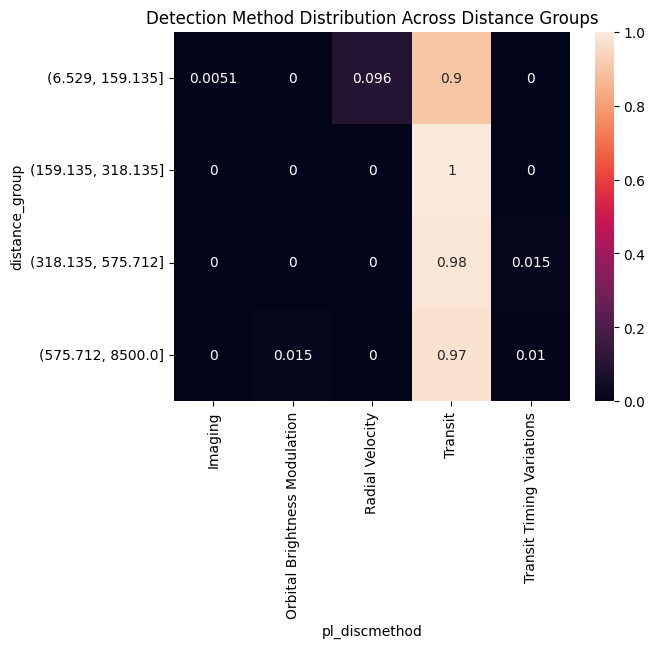

In [42]:
plt.figure()
sns.heatmap(validation_table, annot=True)
plt.title("Detection Method Distribution Across Distance Groups")
plt.show()

This heatmap shows how exoplanet detection methods vary across different distance groups.  
It helps identify whether certain methods are more effective or dominant at specific observational ranges.

#18. Normalized Crosstab

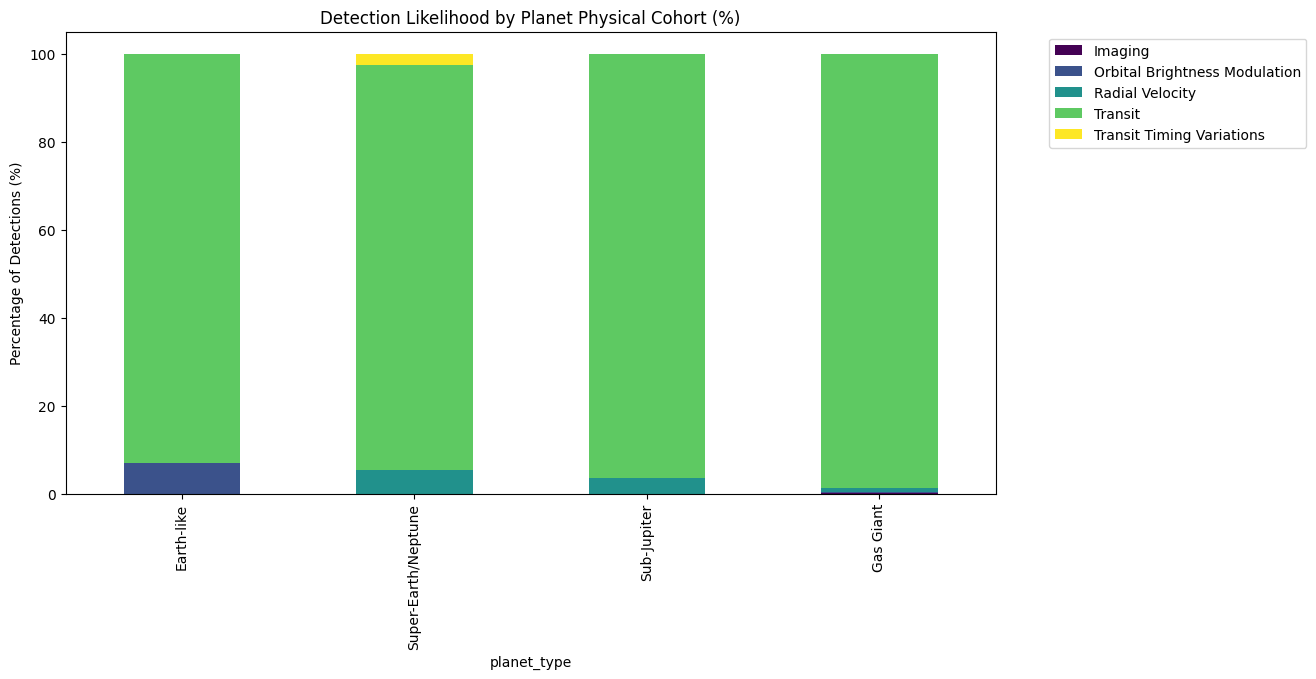

In [43]:
# Advanced Technique: Normalized Cross-tabulation
# This shows the percentage (not just count) of planet types found by method
ct_norm = pd.crosstab(df_cleaned['planet_type'], df_cleaned['pl_discmethod'], normalize='index') * 100

ct_norm.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Detection Likelihood by Planet Physical Cohort (%)')
plt.ylabel('Percentage of Detections (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

This normalized cross-tabulation highlights the relative dominance of detection methods across distance groups.  
By using proportions instead of raw counts, it reveals true patterns without bias from sample size differences.